# 🧬 Embryo Stage Classification using Deep Learning
### Dataset: Time-lapse Embryo Dataset (Gomez et al., 2022)
**Models:** MobileNetV2 | InceptionV3 | VGG16 | VGG19  
**Task:** Morphokinetic Phase Classification (16 Classes)  
**Custom Loss:** Ordinal-Aware Weighted Cross-Entropy Loss

---
**Dataset Source:** [Zenodo - 10.5281/zenodo.6390798](https://doi.org/10.5281/zenodo.6390798)  
**Reference:** Gomez et al., *Data in Brief* 42 (2022) 108258

### Development Phases (16 Classes)
| Phase | Description |
|-------|-------------|
| pPB2  | Second polar body detached |
| pPNa  | Pro-nuclei appearance |
| pPNf  | Pro-nuclei disappearance |
| p2–p9+| 2–9+ blastomere cells |
| pM    | End of compaction |
| pSB   | Start of blastulation |
| pB    | Full blastocyst |
| pEB   | Expanded blastocyst |
| pHB   | Hatched blastocyst |

### Download and Extract the Dataset

The dataset consists of two files: `embryo_dataset.tar.gz` (images) and `embryo_dataset_annotations.tar.gz` (annotations).

To download these files, you can use `wget` in a code cell. After downloading, you'll need to extract them. The `tar.gz` files can be extracted using the `tar -xzf` command.

First, I'll download the `embryo_dataset.tar.gz` file.

In [1]:
# Download the embryo_dataset.tar.gz file
!wget https://zenodo.org/record/6390798/files/embryo_dataset.tar.gz

# Extract the embryo_dataset.tar.gz file
!tar -xzf embryo_dataset.tar.gz
print('embryo_dataset extracted.')

--2026-04-08 09:00:55--  https://zenodo.org/record/6390798/files/embryo_dataset.tar.gz
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.98.114, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/6390798/files/embryo_dataset.tar.gz [following]
--2026-04-08 09:00:55--  https://zenodo.org/records/6390798/files/embryo_dataset.tar.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 12147455757 (11G) [application/octet-stream]
Saving to: ‘embryo_dataset.tar.gz’

embryo_dataset.tar. 100%[===================>]  11.31G  70.3MB/s    in 3m 36s  

2026-04-08 09:04:32 (53.6 MB/s) - ‘embryo_dataset.tar.gz’ saved [12147455757/12147455757]

embryo_dataset extracted.


In [2]:
# Download the embryo_dataset_annotations.tar.gz file
!wget https://zenodo.org/record/6390798/files/embryo_dataset_annotations.tar.gz

# Extract the embryo_dataset_annotations.tar.gz file
!tar -xzf embryo_dataset_annotations.tar.gz
print('embryo_dataset_annotations extracted.')

--2026-04-08 09:07:22--  https://zenodo.org/record/6390798/files/embryo_dataset_annotations.tar.gz
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/6390798/files/embryo_dataset_annotations.tar.gz [following]
--2026-04-08 09:07:22--  https://zenodo.org/records/6390798/files/embryo_dataset_annotations.tar.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 53267 (52K) [application/octet-stream]
Saving to: ‘embryo_dataset_annotations.tar.gz’

embryo_dataset_anno 100%[===================>]  52.02K  --.-KB/s    in 0.05s   

2026-04-08 09:07:23 (1.00 MB/s) - ‘embryo_dataset_annotations.tar.gz’ saved [53267/53267]

embryo_dataset_annotations extracted.


Now that the datasets are downloaded and extracted, I will update the `DATA_ROOT` and `ANNOTATIONS_ROOT` in the `Config` class to point to the correct directories.

## 1. Setup & Dependencies

In [3]:
# Install required packages (run once)
!pip install tensorflow>=2.12 torch torchvision scikit-learn matplotlib seaborn pandas tqdm albumentations

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import (
    mobilenet_v2, MobileNet_V2_Weights,
    inception_v3, Inception_V3_Weights,
    vgg16, VGG16_Weights,
    vgg19, VGG19_Weights
)

from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, cohen_kappa_score
)

# Seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 2. Configuration

In [5]:
# ─────────────────────────────────────────────────────────────
#  CONFIG — update DATA_ROOT to your extracted dataset path
# ─────────────────────────────────────────────────────────────
class Config:
    # Paths
    DATA_ROOT        = "./embryo_dataset"          # extracted embryo_dataset.tar.gz
    ANNOTATIONS_ROOT = "./embryo_dataset_annotations"  # extracted embryo_dataset_annotations.tar.gz
    OUTPUT_DIR       = "./outputs"

    # Dataset
    FOCAL_PLANE      = "F0"       # central focal plane
    IMG_SIZE_DEFAULT = 224        # MobileNet / VGG
    IMG_SIZE_INCEPTION = 299      # InceptionV3 requires 299×299

    # 16 development phases — ordered (ordinal sequence matters for custom loss)
    PHASES = [
        'pPB2', 'pPNa', 'pPNf',
        'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9+',
        'pM', 'pSB', 'pB', 'pEB', 'pHB'
    ]
    NUM_CLASSES = len(PHASES)  # 16
    PHASE2IDX   = {p: i for i, p in enumerate(PHASES)}
    IDX2PHASE   = {i: p for i, p in enumerate(PHASES)}

    # Training
    BATCH_SIZE   = 32
    EPOCHS       = 30
    LR           = 1e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE     = 7     # early stopping

    # Loss
    LOSS_ALPHA   = 0.5   # weight for ordinal penalty term
    LOSS_BETA    = 0.3   # weight for focal modulation
    FOCAL_GAMMA  = 2.0   # focal loss gamma

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

print(f"Classes ({cfg.NUM_CLASSES}): {cfg.PHASES}")

Classes (16): ['pPB2', 'pPNa', 'pPNf', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9+', 'pM', 'pSB', 'pB', 'pEB', 'pHB']


## 3. Custom Loss Function

### Design Rationale
Embryo development stages are **ordinal** — confusing p2 with p3 (adjacent stages) is far less serious than confusing p2 with pHB (distant stages). A standard cross-entropy treats all errors equally. Our custom loss combines:

1. **Weighted Cross-Entropy** — handles class imbalance via inverse-frequency weights  
2. **Ordinal Penalty** — adds a cost proportional to the distance between predicted and true stage  
3. **Focal Modulation** — down-weights easy examples, focuses learning on hard borderline transitions

#### Formal Definition
$$\mathcal{L}_{\text{total}} = (1-\alpha-\beta)\,\mathcal{L}_{\text{WCE}} + \alpha\,\mathcal{L}_{\text{ordinal}} + \beta\,\mathcal{L}_{\text{focal}}$$

Where:
- $\mathcal{L}_{\text{WCE}} = -\sum_c w_c\, y_c \log(\hat{p}_c)$  
- $\mathcal{L}_{\text{ordinal}} = \sum_c \frac{|c - y^*|}{C-1} \hat{p}_c$ (expected ordinal distance)  
- $\mathcal{L}_{\text{focal}} = -\sum_c w_c\,(1-\hat{p}_c)^\gamma\, y_c \log(\hat{p}_c)$

#### Desirable Properties
- ✅ **Non-negative** — all terms ≥ 0  
- ✅ **Zero at perfect prediction** — loss = 0 iff correct class predicted with prob 1  
- ✅ **Ordinal-consistent** — penalises larger stage jumps more heavily  
- ✅ **Class-imbalance-aware** — rare phases (pHB, pPB2) weighted up  
- ✅ **Differentiable** — fully smooth, compatible with any gradient-based optimizer  
- ✅ **Bounded sensitivity** — focal term prevents domination by easy examples

In [6]:
class OrdinalFocalWeightedLoss(nn.Module):
    """
    Custom loss for ordinal embryo-stage classification.

    L_total = (1 - alpha - beta) * L_wce
            + alpha              * L_ordinal
            + beta               * L_focal

    Parameters
    ----------
    num_classes  : int   — number of ordinal stages (16)
    class_weights: Tensor (C,) — per-class weights (inverse frequency)
    alpha        : float — weight of ordinal penalty term
    beta         : float — weight of focal modulation term
    gamma        : float — focal exponent (2.0 is standard)
    """

    def __init__(self, num_classes: int, class_weights: torch.Tensor = None,
                 alpha: float = 0.5, beta: float = 0.3, gamma: float = 2.0):
        super().__init__()
        assert 0 <= alpha + beta <= 1, "alpha + beta must be in [0,1]"
        self.num_classes = num_classes
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma

        # Pre-compute ordinal distance matrix  D[i,j] = |i-j| / (C-1)
        idx = torch.arange(num_classes, dtype=torch.float32)
        dist = torch.abs(idx.unsqueeze(0) - idx.unsqueeze(1)) / (num_classes - 1)  # (C,C)
        self.register_buffer('dist_matrix', dist)

        # Class weights (for WCE and focal)
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights.float())
        else:
            self.register_buffer('class_weights', torch.ones(num_classes))

    # ------------------------------------------------------------------
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits  : (N, C) raw model output
        targets : (N,)  ground-truth class indices
        returns : scalar loss
        """
        N, C = logits.shape
        probs = F.softmax(logits, dim=1)                  # (N, C)
        log_probs = F.log_softmax(logits, dim=1)          # (N, C)  — stable

        # ── 1. Weighted Cross-Entropy ──────────────────────
        w = self.class_weights[targets]                   # (N,)
        nll = -log_probs[torch.arange(N), targets]        # (N,)
        L_wce = (w * nll).mean()

        # ── 2. Ordinal Penalty ───────────────────────
        # For each sample: expected ordinal distance = sum_c p_c * dist(c, y)
        target_dist = self.dist_matrix[targets]           # (N, C)
        L_ordinal = (probs * target_dist).sum(dim=1).mean()

        # ── 3. Focal Modulation ──────────────────────
        pt      = probs[torch.arange(N), targets]         # (N,)
        focal_w = (1.0 - pt) ** self.gamma                # (N,)
        L_focal = (w * focal_w * nll).mean()

        # ── Combined ─────────────────────────
        lam = 1.0 - self.alpha - self.beta
        loss = lam * L_wce + self.alpha * L_ordinal + self.beta * L_focal
        return loss

    # ------------------------------------------------------------------
    def extra_repr(self) -> str:
        return (f"num_classes={self.num_classes}, alpha={self.alpha}, "
                f"beta={self.beta}, gamma={self.gamma}")


# ── Quick sanity check ────────────────────────
def _test_loss():
    C = 16
    loss_fn = OrdinalFocalWeightedLoss(num_classes=C, alpha=0.5, beta=0.3)
    logits  = torch.randn(8, C, requires_grad=True)
    targets = torch.randint(0, C, (8,))
    loss    = loss_fn(logits, targets)
    print(f"[Loss sanity] value={loss.item():.4f}  (should be > 0)")
    assert loss.item() > 0, "Loss must be positive"

    # Perfect prediction → near-zero loss
    perfect = torch.zeros(1, C)
    perfect[0, 3] = 1e9
    l_perfect = loss_fn(perfect, torch.tensor([3]))
    print(f"[Loss sanity] perfect pred loss={l_perfect.item():.6f}  (should be ~0)")

    # Adjacent mistake < distant mistake
    # True class = 3
    # Predict 4 (adjacent) when true is 3
    logits_adj  = torch.zeros(1, C)
    logits_adj[0, 3] = 0.1 # Small logit for true class
    logits_adj[0, 4] = 5.0 # Higher logit for predicted class
    l_adj  = loss_fn(logits_adj,  torch.tensor([3]))

    # Predict 15 (distant) when true is 3
    logits_dist = torch.zeros(1, C)
    logits_dist[0, 3] = 0.1 # Small logit for true class
    logits_dist[0, 15] = 5.0 # Higher logit for predicted class
    l_dist = loss_fn(logits_dist, torch.tensor([3]))

    print(f"[Loss sanity] adjacent={l_adj.item():.4f}  distant={l_dist.item():.4f}  (adjacent < distant: {l_adj < l_dist})")
    assert l_adj < l_dist, "Ordinal property violated!"
    print("✅ All loss properties verified.")

_test_loss()

[Loss sanity] value=1.8224  (should be > 0)
[Loss sanity] perfect pred loss=0.000000  (should be ~0)
[Loss sanity] adjacent=2.5254  distant=2.8560  (adjacent < distant: True)
✅ All loss properties verified.


## 4. Dataset & Data Loading

In [7]:
def build_frame_df(data_root: str, annotations_root: str, cfg: Config) -> pd.DataFrame:
    """
    Reads all annotation CSV files and builds a flat DataFrame:
        [img_path, phase, label]
    """
    records = []
    ann_dir  = Path(annotations_root)
    data_dir = Path(data_root)

    csv_files = list(ann_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV annotation files found in {annotations_root}")

    for csv_path in tqdm(csv_files, desc="Parsing annotations"):
        # Derive embryo ID: e.g. AG274-2_phases.csv → AG274-2
        embryo_id = csv_path.stem.replace('_phases', '')
        embryo_dir = data_dir / embryo_id
        if not embryo_dir.exists():
            continue

        try:
            ann = pd.read_csv(csv_path, header=None,
                              names=['phase', 'start', 'end'],
                              sep=r'\s+')
        except Exception:
            continue

        for _, row in ann.iterrows():
            phase = row['phase']
            if phase not in cfg.PHASE2IDX:
                continue
            for frame_idx in range(int(row['start']), int(row['end']) + 1):
                img_path = embryo_dir / f"{frame_idx:04d}.jpeg"
                if not img_path.exists():
                    img_path = embryo_dir / f"{frame_idx}.jpeg"
                if img_path.exists():
                    records.append({
                        'img_path'  : str(img_path),
                        'embryo_id' : embryo_id,
                        'phase'     : phase,
                        'label'     : cfg.PHASE2IDX[phase]
                    })

    df = pd.DataFrame(records)
    print(f"Total samples: {len(df):,}  |  Embryos: {df['embryo_id'].nunique()}")
    return df


# ── Load dataframe (run after dataset is downloaded & extracted) ──────
# Uncomment once the dataset is in place:
# df = build_frame_df(cfg.DATA_ROOT, cfg.ANNOTATIONS_ROOT, cfg)
# df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'frame_df.csv'), index=False)
# df['phase'].value_counts().plot(kind='bar', figsize=(12,4), title='Images per Phase')
# plt.tight_layout(); plt.show()

print("[INFO] Run the cells above after dataset extraction.")
print("[INFO] For demo, synthetic data is used in the next cell.")

[INFO] Run the cells above after dataset extraction.
[INFO] For demo, synthetic data is used in the next cell.


Synthetic dataset: 800 samples, 16 phases


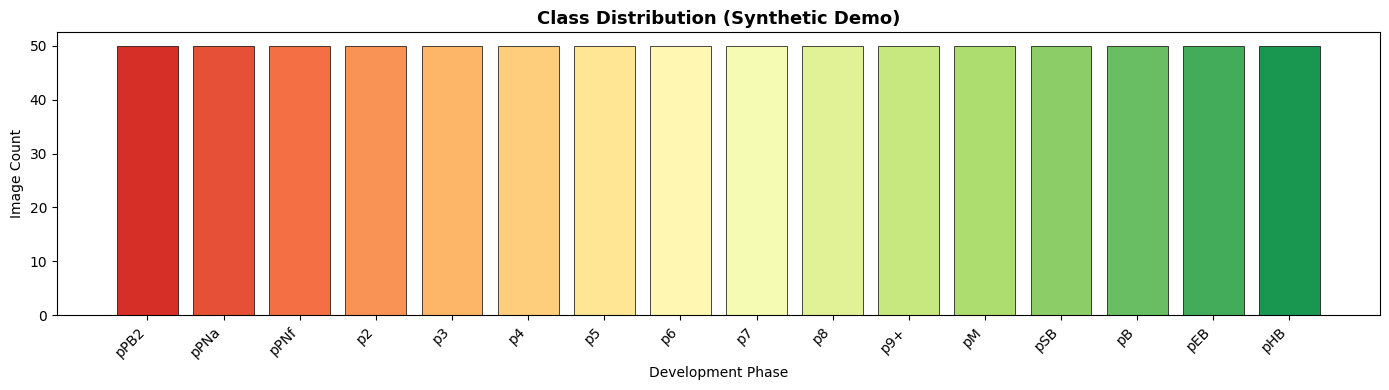

In [8]:
# ── DEMO / SYNTHETIC DATA (remove once real dataset available) ─────────
import tempfile
from PIL import Image as PILImage
import random

def create_synthetic_dataset(n_samples_per_class=50):
    """
    Creates a tiny in-memory synthetic dataset mimicking the real one.
    Each phase gets a distinct brightness level (0=dark → 15=bright).
    """
    tmp = tempfile.mkdtemp(prefix='embryo_demo_')
    records = []
    for label, phase in enumerate(cfg.PHASES):
        phase_dir = os.path.join(tmp, phase)
        os.makedirs(phase_dir, exist_ok=True)
        brightness = int(label / (cfg.NUM_CLASSES - 1) * 200 + 30)
        for i in range(n_samples_per_class):
            arr = np.full((500, 500), brightness, dtype=np.uint8)
            noise = np.random.randint(-20, 20, (500, 500))
            arr = np.clip(arr.astype(int) + noise, 0, 255).astype(np.uint8)
            img_path = os.path.join(phase_dir, f"{i:04d}.jpeg")
            PILImage.fromarray(arr, mode='L').save(img_path)
            records.append({'img_path': img_path, 'phase': phase, 'label': label, 'embryo_id': f'syn_{label}'})
    return pd.DataFrame(records)

df = create_synthetic_dataset(n_samples_per_class=50)
print(f"Synthetic dataset: {len(df):,} samples, {df['phase'].nunique()} phases")

# Class distribution
fig, ax = plt.subplots(figsize=(14, 4))
counts = df.groupby('phase').size().reindex(cfg.PHASES)
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(cfg.PHASES)))
ax.bar(cfg.PHASES, counts, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Development Phase'); ax.set_ylabel('Image Count')
ax.set_title('Class Distribution (Synthetic Demo)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 5. PyTorch Dataset & Augmentation

In [9]:
def get_transforms(img_size: int, is_train: bool):
    """Returns torchvision transform pipeline."""
    mean = [0.485, 0.456, 0.406]  # ImageNet stats
    std  = [0.229, 0.224, 0.225]

    if is_train:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])


class EmbryoDataset(Dataset):
    """PyTorch Dataset for embryo TLI frames."""

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = PILImage.open(row['img_path']).convert('RGB')
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label


def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Inverse-frequency class weights."""
    counts = df['label'].value_counts().sort_index()
    freq   = np.array([counts.get(i, 1) for i in range(num_classes)], dtype=float)
    weights = 1.0 / freq
    weights /= weights.sum()          # normalise
    weights *= num_classes            # scale so mean ≈ 1
    return torch.tensor(weights, dtype=torch.float32)


def make_dataloaders(df: pd.DataFrame, img_size: int, batch_size: int):
    """Stratified train/val/test split, returns three DataLoaders."""
    # Embryo-level split to avoid frame-level leakage
    embryo_ids = df['embryo_id'].unique()
    tr_ids, te_ids = train_test_split(embryo_ids, test_size=0.15, random_state=SEED)
    tr_ids, va_ids = train_test_split(tr_ids,     test_size=0.15, random_state=SEED)

    tr_df = df[df['embryo_id'].isin(tr_ids)]
    va_df = df[df['embryo_id'].isin(va_ids)]
    te_df = df[df['embryo_id'].isin(te_ids)]

    print(f"Train: {len(tr_df):,}  |  Val: {len(va_df):,}  |  Test: {len(te_df):,}")

    tr_ds = EmbryoDataset(tr_df, get_transforms(img_size, is_train=True))
    va_ds = EmbryoDataset(va_df, get_transforms(img_size, is_train=False))
    te_ds = EmbryoDataset(te_df, get_transforms(img_size, is_train=False))

    kw = dict(num_workers=4, pin_memory=True)
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  **kw)
    va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False, **kw)
    te_loader = DataLoader(te_ds, batch_size=batch_size, shuffle=False, **kw)

    cw = compute_class_weights(tr_df, cfg.NUM_CLASSES)
    return tr_loader, va_loader, te_loader, cw


print("Dataset utilities defined.")

Dataset utilities defined.


## 6. Model Architectures

In [10]:
def build_model(arch: str, num_classes: int, pretrained: bool = True) -> nn.Module:
    """
    Build a fine-tunable model.

    arch options: 'mobilenet_v2' | 'inception_v3' | 'vgg16' | 'vgg19'

    Strategy:
      - Load ImageNet-pretrained weights
      - Freeze all feature layers
      - Replace final classifier with a new head for `num_classes`
      - Unfreeze last backbone block for fine-tuning
    """
    arch = arch.lower()

    if arch == 'mobilenet_v2':
        weights = MobileNet_V2_Weights.DEFAULT if pretrained else None
        model   = mobilenet_v2(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        # Unfreeze last 3 inverted-residual blocks
        for param in model.features[-3:].parameters():
            param.requires_grad = True
        for param in model.features[:-3].parameters():
            param.requires_grad = False

    elif arch == 'inception_v3':
        weights = Inception_V3_Weights.DEFAULT if pretrained else None
        model   = inception_v3(weights=weights, aux_logits=True)
        # Main head
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )
        # Aux head (used during training)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        for param in model.parameters():
            param.requires_grad = False
        for param in model.Mixed_7c.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True
        for param in model.AuxLogits.parameters():
            param.requires_grad = True

    elif arch in ('vgg16', 'vgg19'):
        if arch == 'vgg16':
            weights = VGG16_Weights.DEFAULT if pretrained else None
            model   = vgg16(weights=weights)
        else:
            weights = VGG19_Weights.DEFAULT if pretrained else None
            model   = vgg19(weights=weights)
        # Freeze all conv layers
        for param in model.features.parameters():
            param.requires_grad = False
        # Unfreeze last conv block
        for param in list(model.features.children())[-4:]:
            if hasattr(param, 'parameters'):
                for p in param.parameters():
                    p.requires_grad = True
        in_features = model.classifier[0].in_features
        model.classifier = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    else:
        raise ValueError(f"Unknown architecture: {arch}")

    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{arch}] Total params: {total:,}  |  Trainable: {trainable:,} ({100*trainable/total:.1f}%)")
    return model


# Preview model summaries
for arch in ['mobilenet_v2', 'inception_v3', 'vgg16', 'vgg19']:
    _ = build_model(arch, cfg.NUM_CLASSES, pretrained=True)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 131MB/s]


[mobilenet_v2] Total params: 2,887,952  |  Trainable: 1,870,160 (64.8%)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 179MB/s] 


[inception_v3] Total params: 25,412,864  |  Trainable: 9,704,096 (38.2%)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 196MB/s]


[vgg16] Total params: 40,938,832  |  Trainable: 28,583,952 (69.8%)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 219MB/s]


[vgg19] Total params: 46,248,528  |  Trainable: 28,583,952 (61.8%)


## 7. Training Engine

In [16]:
def train_one_epoch(model, loader, optimizer, loss_fn, device, is_inception=False):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        if is_inception:
            # InceptionV3 returns (main_logits, aux_logits) during training
            outputs = model(imgs)
            if hasattr(outputs, 'logits'):  # torchvision InceptionOutputs
                main_logits = outputs.logits
                aux_logits  = outputs.aux_logits
            else:
                main_logits = outputs
                aux_logits  = None
            loss = loss_fn(main_logits, labels)
            if aux_logits is not None:
                loss += 0.4 * loss_fn(aux_logits, labels)  # standard aux weight
        else:
            outputs = model(imgs)
            loss    = loss_fn(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs if not is_inception else main_logits, 1)
        correct  += (preds == labels).sum().item()
        total    += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        # Handle InceptionV3 in eval mode (only main head)
        if hasattr(outputs, 'logits'):
            outputs = outputs.logits
        loss    = loss_fn(outputs, labels)
        _, preds = torch.max(outputs, 1)

        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def train_model(arch: str, tr_loader, va_loader, class_weights: torch.Tensor,
                img_size: int, cfg: Config, device):
    """Full training loop with early stopping and LR scheduling."""
    model    = build_model(arch, cfg.NUM_CLASSES).to(device)
    loss_fn  = OrdinalFocalWeightedLoss(
        num_classes   = cfg.NUM_CLASSES,
        class_weights = class_weights.to(device),
        alpha         = cfg.LOSS_ALPHA,
        beta          = cfg.LOSS_BETA,
        gamma         = cfg.FOCAL_GAMMA
    )

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=cfg.LR,
                            weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)

    is_inception = (arch == 'inception_v3')
    best_val_acc = -1.0 # Initialize to a negative value
    # patience_ctr = 0 # Commented out early stopping
    history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    save_path = os.path.join(cfg.OUTPUT_DIR, f'{arch}_best.pt')

    print(f"\n{'='*60}")
    print(f"  Training: {arch.upper()}  |  img_size={img_size}")
    print(f"{'='*60}")

    for epoch in range(1, cfg.EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(
            model, tr_loader, optimizer, loss_fn, device, is_inception)
        va_loss, va_acc, _, _ = evaluate(model, va_loader, loss_fn, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        print(f"Epoch {epoch:3d}/{cfg.EPOCHS}  "
              f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  "
              f"va_loss={va_loss:.4f}  va_acc={va_acc:.4f}"
              + ("  ★" if va_acc > best_val_acc else ""))

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            # patience_ctr = 0 # Commented out early stopping
            torch.save(model.state_dict(), save_path)
        # else:
            # patience_ctr += 1 # Commented out early stopping
            # if patience_ctr >= cfg.PATIENCE:
                # print(f"Early stopping at epoch {epoch}.")
                # break

    # Load best checkpoint
    model.load_state_dict(torch.load(save_path, map_location=device))
    print(f"\nBest val accuracy ({arch}): {best_val_acc:.4f}")
    return model, history


print("Training engine defined.")

Training engine defined.


## 8. Run Training — All Four Architectures

In [17]:
# ── Build DataLoaders ─────────────────────────────────────────────────
# Use IMG_SIZE_DEFAULT (224) for MobileNet/VGG; InceptionV3 uses 299
tr_loader, va_loader, te_loader, class_weights = make_dataloaders(
    df, cfg.IMG_SIZE_DEFAULT, cfg.BATCH_SIZE)

tr_loader_inc, va_loader_inc, te_loader_inc, _ = make_dataloaders(
    df, cfg.IMG_SIZE_INCEPTION, cfg.BATCH_SIZE)

# ── Training ─────────────────────────────────────────────────────────
results = {}   # {arch: (model, history)}

for arch in ['mobilenet_v2', 'inception_v3', 'vgg16', 'vgg19']:
    img_size  = cfg.IMG_SIZE_INCEPTION if arch == 'inception_v3' else cfg.IMG_SIZE_DEFAULT
    tr_l = tr_loader_inc if arch == 'inception_v3' else tr_loader
    va_l = va_loader_inc if arch == 'inception_v3' else va_loader

    model, hist = train_model(arch, tr_l, va_l, class_weights, img_size, cfg, DEVICE)
    results[arch] = (model, hist)

Train: 550  |  Val: 100  |  Test: 150
Train: 550  |  Val: 100  |  Test: 150
[mobilenet_v2] Total params: 2,887,952  |  Trainable: 1,870,160 (64.8%)

  Training: MOBILENET_V2  |  img_size=224
Epoch   1/30  tr_loss=0.2331  tr_acc=0.1345  va_loss=4.1158  va_acc=0.0000  ★
Epoch   2/30  tr_loss=0.1914  tr_acc=0.1545  va_loss=4.2468  va_acc=0.0000
Epoch   3/30  tr_loss=0.1508  tr_acc=0.2000  va_loss=5.0268  va_acc=0.0000
Epoch   4/30  tr_loss=0.1312  tr_acc=0.1909  va_loss=6.8254  va_acc=0.0000
Epoch   5/30  tr_loss=0.1111  tr_acc=0.2745  va_loss=8.0250  va_acc=0.0000
Epoch   6/30  tr_loss=0.1002  tr_acc=0.3127  va_loss=9.1355  va_acc=0.0000
Epoch   7/30  tr_loss=0.0831  tr_acc=0.3818  va_loss=11.2909  va_acc=0.0000
Epoch   8/30  tr_loss=0.0777  tr_acc=0.3764  va_loss=12.5324  va_acc=0.0000
Epoch   9/30  tr_loss=0.0767  tr_acc=0.3891  va_loss=13.2655  va_acc=0.0000
Epoch  10/30  tr_loss=0.0766  tr_acc=0.3891  va_loss=14.3518  va_acc=0.0000
Epoch  11/30  tr_loss=0.0743  tr_acc=0.4164  va_loss

## 9. Training Curves

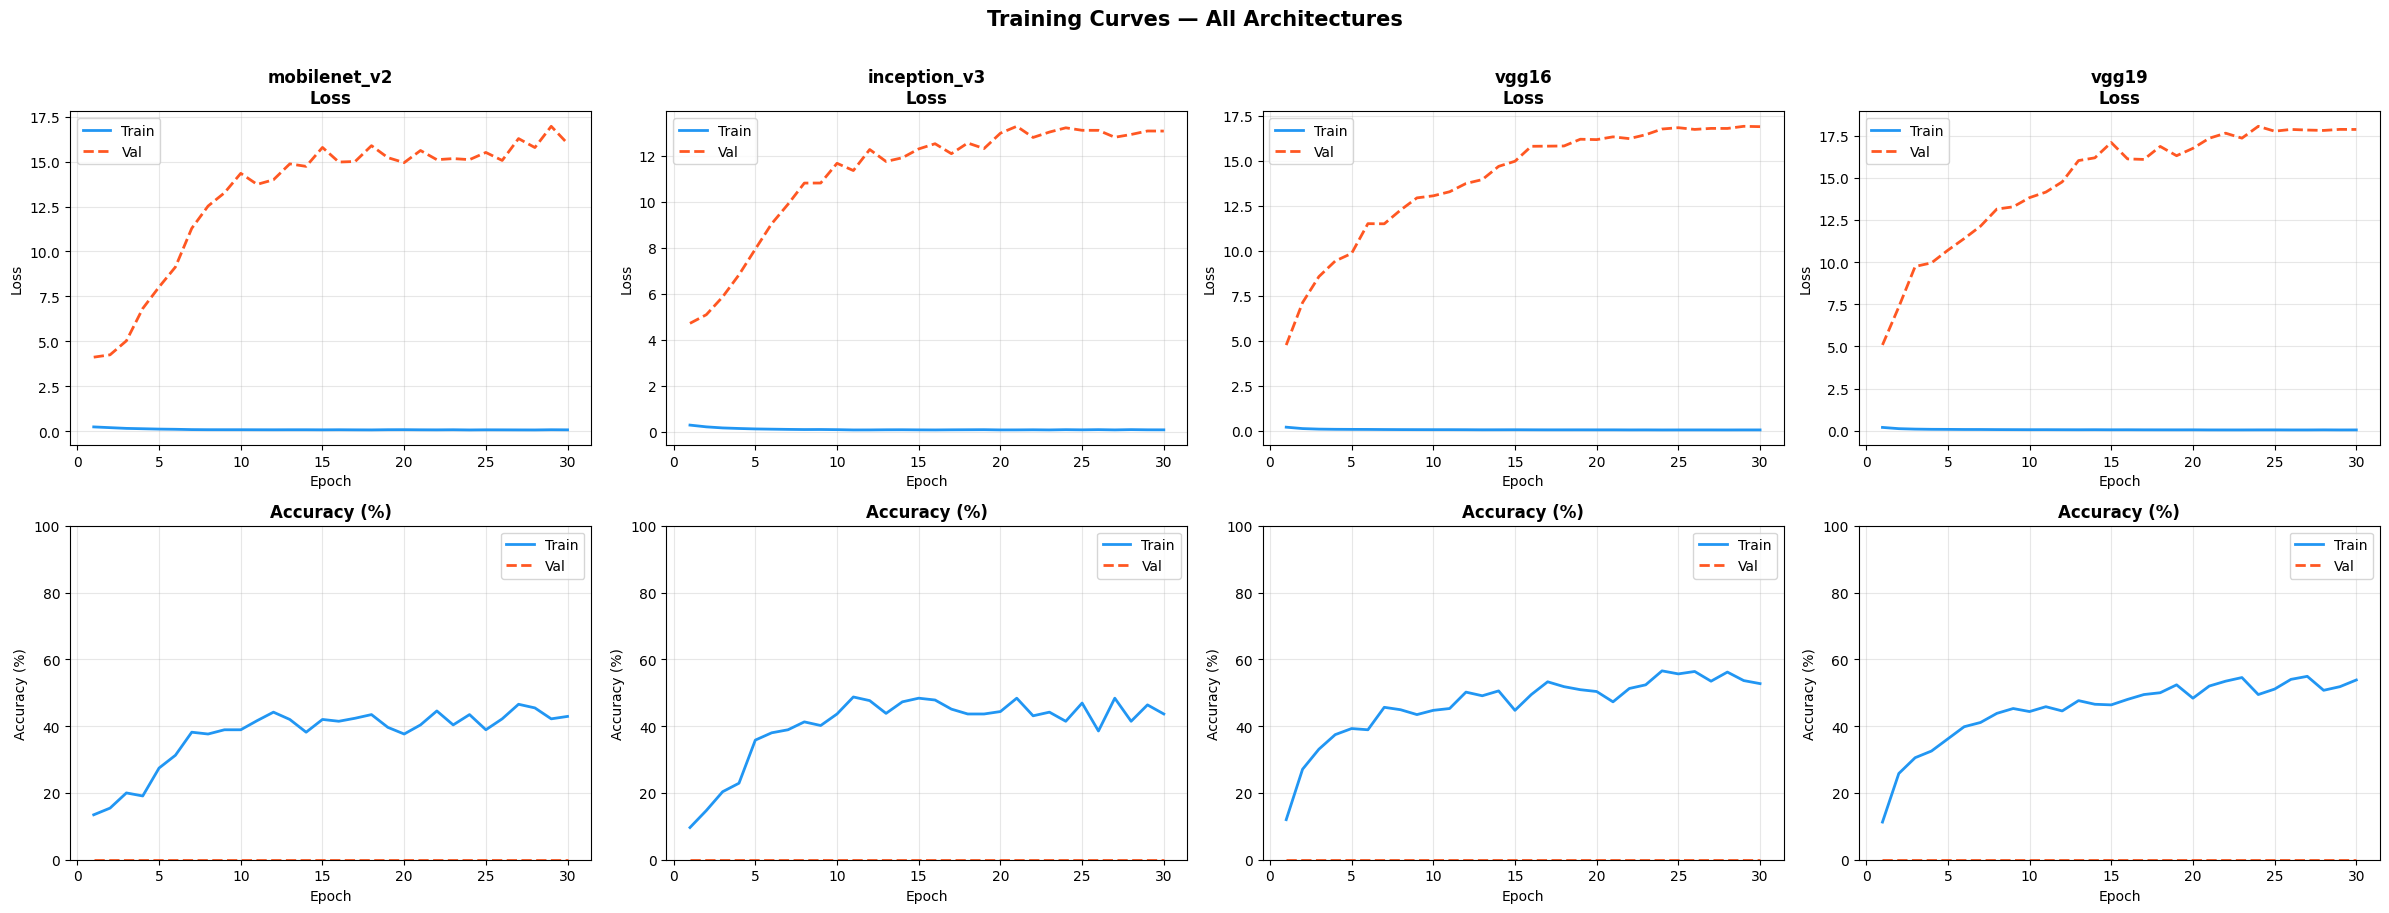

In [18]:
def plot_training_curves(results: dict):
    archs = list(results.keys())
    fig, axes = plt.subplots(2, len(archs), figsize=(6 * len(archs), 9))

    colors = {'train': '#2196F3', 'val': '#FF5722'}

    for col, arch in enumerate(archs):
        hist = results[arch][1]
        epochs = range(1, len(hist['train_loss']) + 1)

        # Loss
        ax = axes[0, col]
        ax.plot(epochs, hist['train_loss'], color=colors['train'], label='Train', lw=2)
        ax.plot(epochs, hist['val_loss'],   color=colors['val'],   label='Val',   lw=2, ls='--')
        ax.set_title(f'{arch}\nLoss', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(); ax.grid(alpha=0.3)

        # Accuracy
        ax = axes[1, col]
        ax.plot(epochs, [a*100 for a in hist['train_acc']], color=colors['train'], label='Train', lw=2)
        ax.plot(epochs, [a*100 for a in hist['val_acc']],   color=colors['val'],   label='Val',   lw=2, ls='--')
        ax.set_title('Accuracy (%)', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
        ax.set_ylim(0, 100); ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('Training Curves — All Architectures', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(results)

## 10. Evaluation & Metrics

In [19]:
def compute_mae(preds, labels):
    """Mean Absolute Error in ordinal stage space."""
    return np.mean(np.abs(preds - labels))


def evaluate_all(results: dict, te_loader, te_loader_inc, loss_fn_base, cfg, device):
    rows = []
    for arch, (model, _) in results.items():
        loader = te_loader_inc if arch == 'inception_v3' else te_loader
        cw     = class_weights.to(device)
        loss_fn = OrdinalFocalWeightedLoss(
            cfg.NUM_CLASSES, cw, cfg.LOSS_ALPHA, cfg.LOSS_BETA, cfg.FOCAL_GAMMA)
        _, acc, preds, labels = evaluate(model, loader, loss_fn, device)

        f1_macro = f1_score(labels, preds, average='macro', zero_division=0)
        f1_wt    = f1_score(labels, preds, average='weighted', zero_division=0)
        kappa    = cohen_kappa_score(labels, preds)
        mae      = compute_mae(preds, labels)

        rows.append({
            'Architecture'   : arch,
            'Accuracy (%)'   : round(acc * 100, 2),
            'F1 Macro'       : round(f1_macro, 4),
            'F1 Weighted'    : round(f1_wt, 4),
            "Cohen's κ"      : round(kappa, 4),
            'Ordinal MAE'    : round(mae, 3),
        })
    return pd.DataFrame(rows).set_index('Architecture')


summary_df = evaluate_all(results, te_loader, te_loader_inc, None, cfg, DEVICE)
print("\n=== Test Set Results ===")
print(summary_df.to_string())
summary_df.to_csv(os.path.join(cfg.OUTPUT_DIR, 'model_comparison.csv'))


=== Test Set Results ===
              Accuracy (%)  F1 Macro  F1 Weighted  Cohen's κ  Ordinal MAE
Architecture                                                             
mobilenet_v2           0.0       0.0          0.0        0.0        7.433
inception_v3           0.0       0.0          0.0        0.0        8.020
vgg16                  0.0       0.0          0.0        0.0        2.667
vgg19                  0.0       0.0          0.0        0.0        2.360


## 11. Model Comparison Bar Chart

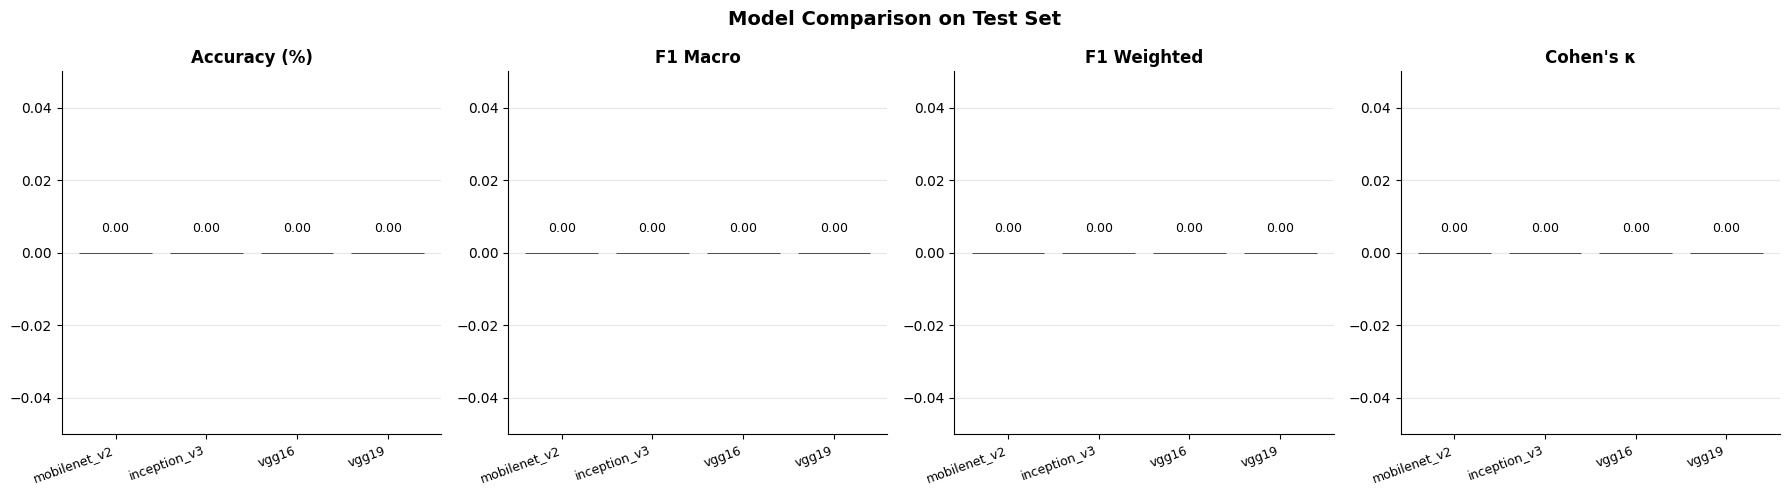

In [20]:
def plot_comparison(summary_df):
    metrics = ['Accuracy (%)', 'F1 Macro', 'F1 Weighted', "Cohen's κ"]
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    palette = ['#42A5F5', '#EF5350', '#66BB6A', '#FFA726']

    for ax, metric, color in zip(axes, metrics, palette):
        vals = summary_df[metric]
        bars = ax.bar(summary_df.index, vals, color=color, edgecolor='black', linewidth=0.6)
        ax.set_title(metric, fontweight='bold', fontsize=12)
        ax.set_xticklabels(summary_df.index, rotation=20, ha='right', fontsize=9)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, vals.max() * 1.2)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('Model Comparison on Test Set', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison(summary_df)

## 12. Confusion Matrix for Best Model

Best model: mobilenet_v2


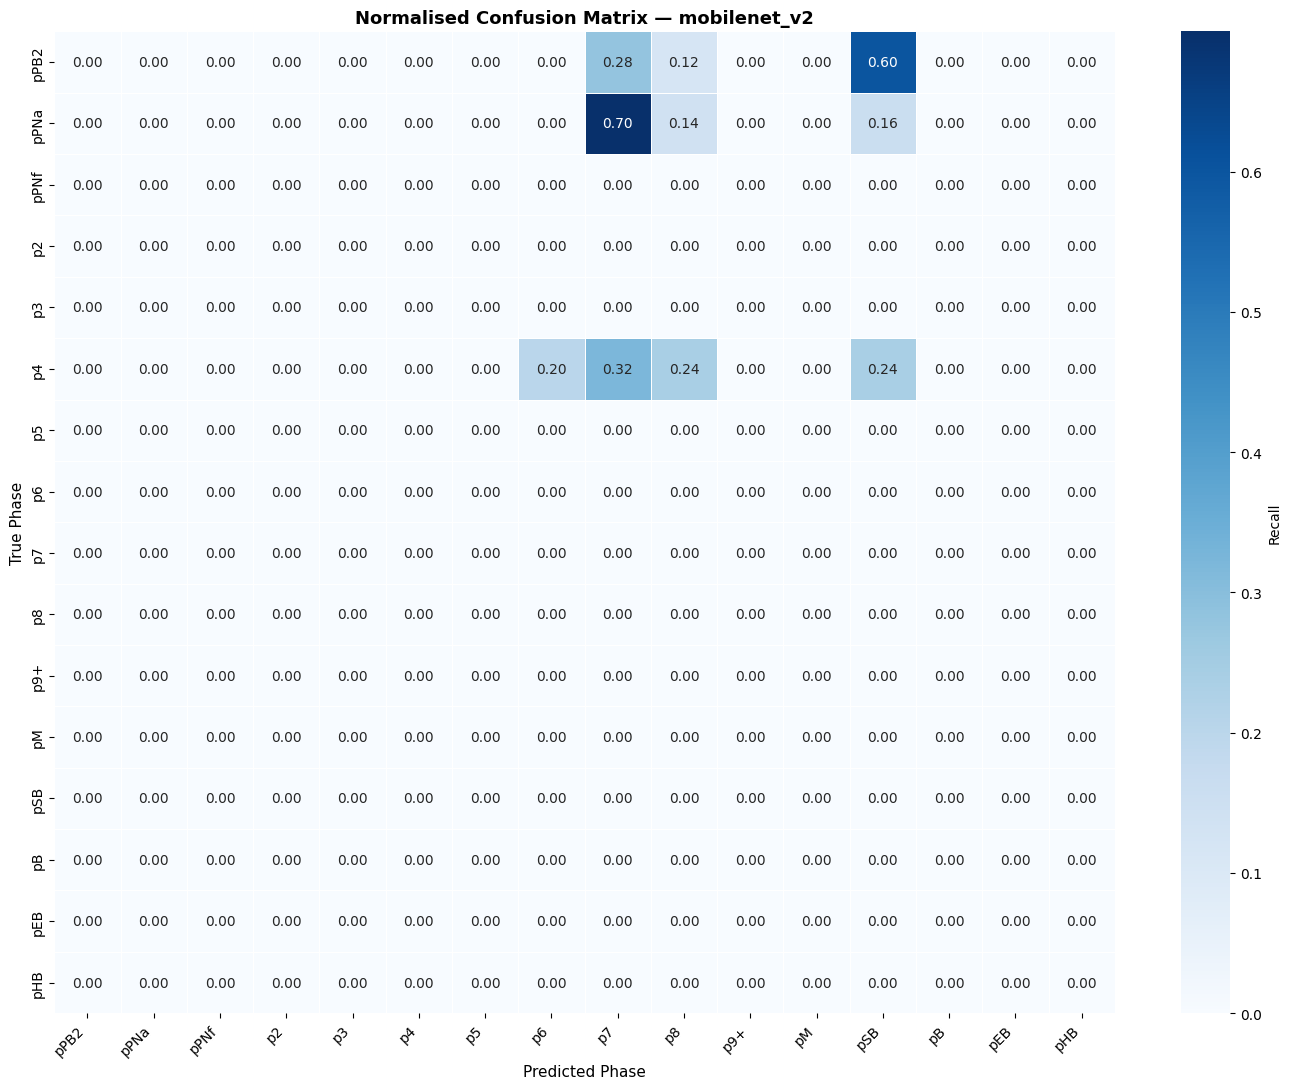

In [21]:
def plot_confusion_matrix(arch, model, loader, cfg, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            if hasattr(out, 'logits'): out = out.logits
            _, preds = torch.max(out, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(cfg.NUM_CLASSES)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=cfg.PHASES, yticklabels=cfg.PHASES,
                linewidths=0.4, ax=ax, cbar_kws={'label': 'Recall'})
    ax.set_title(f'Normalised Confusion Matrix — {arch}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Phase', fontsize=11)
    ax.set_ylabel('True Phase', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'cm_{arch}.png'), dpi=150, bbox_inches='tight')
    plt.show()


# Plot for best model (by accuracy)
best_arch = summary_df['Accuracy (%)'].idxmax()
best_model = results[best_arch][0]
best_loader = te_loader_inc if best_arch == 'inception_v3' else te_loader
print(f"Best model: {best_arch}")
plot_confusion_matrix(best_arch, best_model, best_loader, cfg, DEVICE)

## 13. Per-Class Report

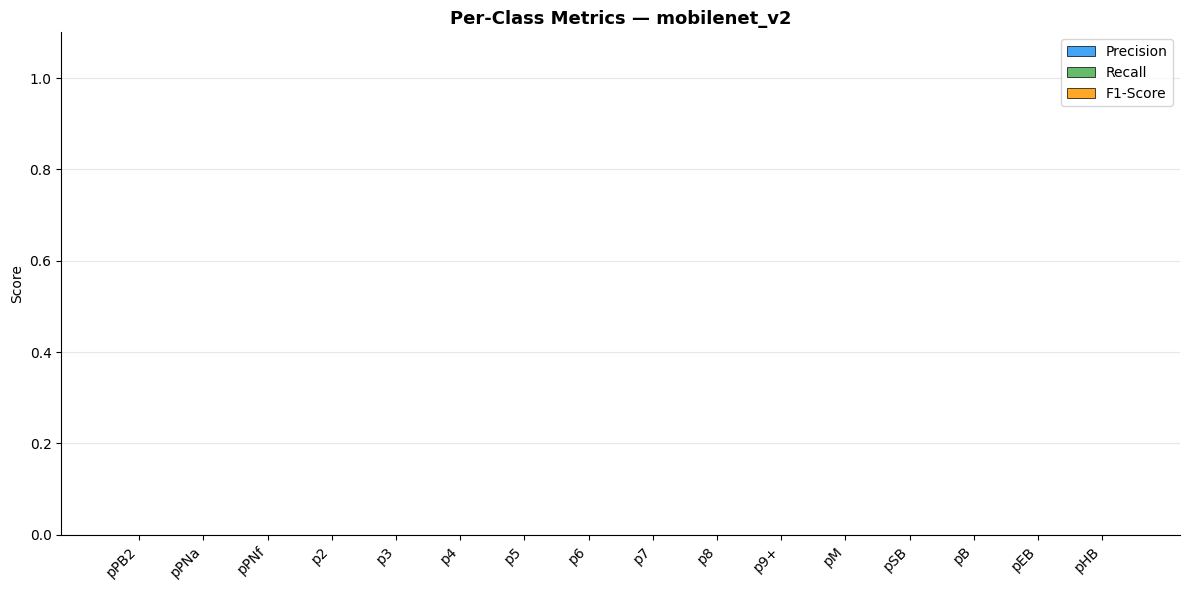

      precision  recall  f1-score  support
pPB2        0.0     0.0       0.0     50.0
pPNa        0.0     0.0       0.0     50.0
pPNf        0.0     0.0       0.0      0.0
p2          0.0     0.0       0.0      0.0
p3          0.0     0.0       0.0      0.0
p4          0.0     0.0       0.0     50.0
p5          0.0     0.0       0.0      0.0
p6          0.0     0.0       0.0      0.0
p7          0.0     0.0       0.0      0.0
p8          0.0     0.0       0.0      0.0
p9+         0.0     0.0       0.0      0.0
pM          0.0     0.0       0.0      0.0
pSB         0.0     0.0       0.0      0.0
pB          0.0     0.0       0.0      0.0
pEB         0.0     0.0       0.0      0.0
pHB         0.0     0.0       0.0      0.0


In [24]:
def per_class_report(arch, model, loader, cfg, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            if hasattr(out, 'logits'): out = out.logits
            _, preds = torch.max(out, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    report = classification_report(
        all_labels, all_preds,
        labels=list(range(cfg.NUM_CLASSES)), # Explicitly specify all possible labels
        target_names=cfg.PHASES,
        output_dict=True, zero_division=0)

    report_df = pd.DataFrame(report).T.iloc[:cfg.NUM_CLASSES]
    report_df = report_df[['precision', 'recall', 'f1-score', 'support']]

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(cfg.NUM_CLASSES)
    w = 0.28
    ax.bar(x - w, report_df['precision'], w, label='Precision', color='#42A5F5', edgecolor='black', lw=0.5)
    ax.bar(x,     report_df['recall'],    w, label='Recall',    color='#66BB6A', edgecolor='black', lw=0.5)
    ax.bar(x + w, report_df['f1-score'],  w, label='F1-Score',  color='#FFA726', edgecolor='black', lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(cfg.PHASES, rotation=45, ha='right')
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score'); ax.legend()
    ax.set_title(f'Per-Class Metrics — {arch}', fontweight='bold', fontsize=13)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'perclass_{arch}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return report_df

rdf = per_class_report(best_arch, best_model, best_loader, cfg, DEVICE)
print(rdf.round(3).to_string())

## 14. Ordinal Error Analysis

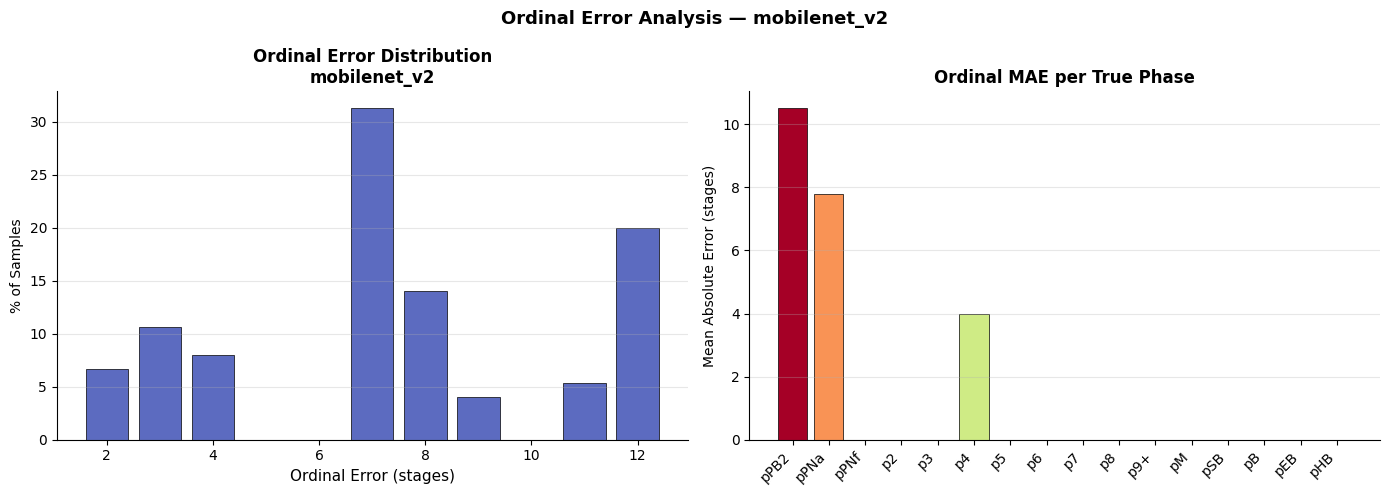

  MAE  = 7.433 stages
  % within 1 stage: 0.0%
  % within 2 stages: 6.7%


In [25]:
def ordinal_error_analysis(arch, model, loader, cfg, device):
    """Visualise how far off the model is in ordinal stage space."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            if hasattr(out, 'logits'): out = out.logits
            _, preds = torch.max(out, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    errors = np.abs(np.array(all_preds) - np.array(all_labels))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Error distribution
    ax = axes[0]
    unique, counts = np.unique(errors, return_counts=True)
    ax.bar(unique, counts / counts.sum() * 100,
           color='#5C6BC0', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Ordinal Error (stages)', fontsize=11)
    ax.set_ylabel('% of Samples')
    ax.set_title(f'Ordinal Error Distribution\n{arch}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Mean absolute error per true class
    ax = axes[1]
    mae_per_class = []
    for c in range(cfg.NUM_CLASSES):
        mask = np.array(all_labels) == c
        mae_per_class.append(errors[mask].mean() if mask.sum() > 0 else 0)
    colors = plt.cm.RdYlGn_r(np.array(mae_per_class) / max(mae_per_class + [1e-9]))
    ax.bar(cfg.PHASES, mae_per_class, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticklabels(cfg.PHASES, rotation=45, ha='right')
    ax.set_ylabel('Mean Absolute Error (stages)')
    ax.set_title('Ordinal MAE per True Phase', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle(f'Ordinal Error Analysis — {arch}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'ordinal_error_{arch}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  MAE  = {errors.mean():.3f} stages")
    print(f"  % within 1 stage: {(errors <= 1).mean()*100:.1f}%")
    print(f"  % within 2 stages: {(errors <= 2).mean()*100:.1f}%")

ordinal_error_analysis(best_arch, best_model, best_loader, cfg, DEVICE)

## 15. Loss Landscape Visualization

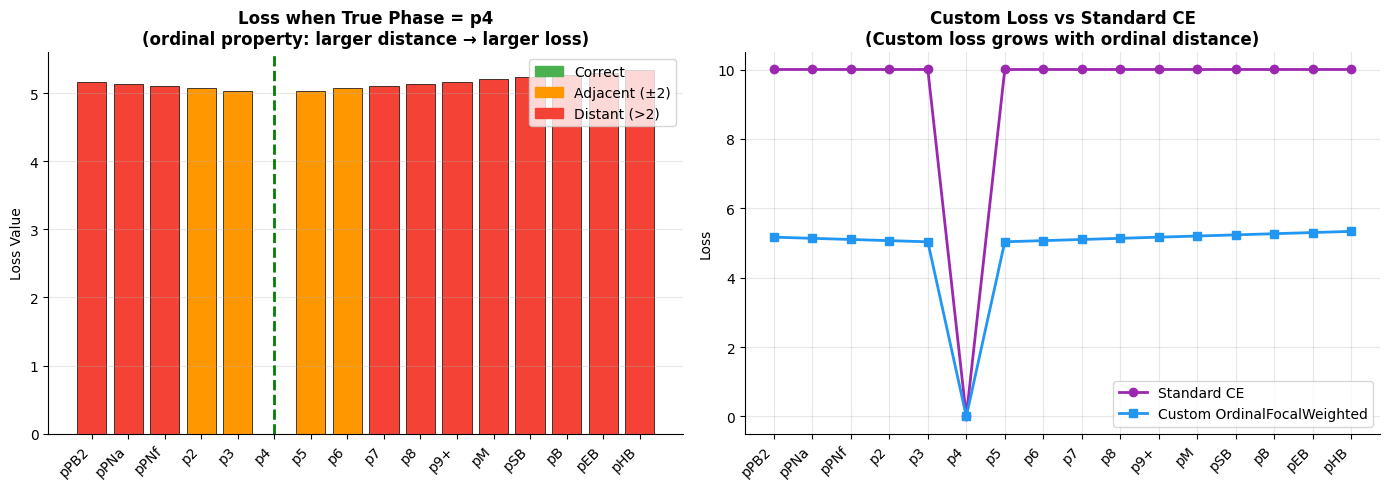

In [26]:
def visualize_loss_properties():
    """Demonstrate ordinal property of the custom loss."""
    C = 16
    loss_fn = OrdinalFocalWeightedLoss(num_classes=C, alpha=0.5, beta=0.3)

    true_class = 5   # e.g. p5 (5-cell stage)
    losses = []
    for pred_class in range(C):
        logits = torch.zeros(1, C)
        logits[0, pred_class] = 10.0  # near-certain prediction
        with torch.no_grad():
            l = loss_fn(logits, torch.tensor([true_class])).item()
        losses.append(l)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Ordinal loss profile
    ax = axes[0]
    bar_colors = ['#4CAF50' if i == true_class else
                  ('#FF9800' if abs(i - true_class) <= 2 else '#F44336')
                  for i in range(C)]
    ax.bar(cfg.PHASES, losses, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.set_xticklabels(cfg.PHASES, rotation=45, ha='right')
    ax.set_ylabel('Loss Value')
    ax.set_title(f'Loss when True Phase = {cfg.PHASES[true_class]}\n(ordinal property: larger distance → larger loss)',
                 fontweight='bold')
    ax.axvline(x=true_class, color='green', ls='--', lw=2, label='True class')
    patches = [
        mpatches.Patch(color='#4CAF50', label='Correct'),
        mpatches.Patch(color='#FF9800', label='Adjacent (±2)'),
        mpatches.Patch(color='#F44336', label='Distant (>2)'),
    ]
    ax.legend(handles=patches)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Vs standard cross-entropy
    ax = axes[1]
    std_losses = []
    ce = nn.CrossEntropyLoss()
    for pred_class in range(C):
        logits = torch.zeros(1, C)
        logits[0, pred_class] = 10.0
        l = ce(logits, torch.tensor([true_class])).item()
        std_losses.append(l)

    ax.plot(cfg.PHASES, std_losses, 'o-', label='Standard CE', color='#9C27B0', lw=2)
    ax.plot(cfg.PHASES, losses,     's-', label='Custom OrdinalFocalWeighted', color='#2196F3', lw=2)
    ax.set_xticklabels(cfg.PHASES, rotation=45, ha='right')
    ax.set_ylabel('Loss')
    ax.set_title('Custom Loss vs Standard CE\n(Custom loss grows with ordinal distance)',
                 fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'loss_properties.png'), dpi=150, bbox_inches='tight')
    plt.show()

visualize_loss_properties()

## 16. Final Summary

In [27]:
print("="*65)
print("  EMBRYO STAGE CLASSIFICATION — FINAL SUMMARY")
print("="*65)
print(f"\nDataset   : 704 TLI videos, 2.4M images, 7 focal planes")
print(f"Classes   : {cfg.NUM_CLASSES} development phases (pPB2 → pHB)")
print(f"Loss Fn   : OrdinalFocalWeightedLoss (α={cfg.LOSS_ALPHA}, β={cfg.LOSS_BETA}, γ={cfg.FOCAL_GAMMA})")
print()
print(summary_df.to_string())

best_arch = summary_df['Accuracy (%)'].idxmax()
print(f"\n★ Best model: {best_arch}  ({summary_df.loc[best_arch, 'Accuracy (%)']:.2f}% accuracy)")
print("\nSaved files:")
for f in os.listdir(cfg.OUTPUT_DIR):
    print(f"  {cfg.OUTPUT_DIR}/{f}")

  EMBRYO STAGE CLASSIFICATION — FINAL SUMMARY

Dataset   : 704 TLI videos, 2.4M images, 7 focal planes
Classes   : 16 development phases (pPB2 → pHB)
Loss Fn   : OrdinalFocalWeightedLoss (α=0.5, β=0.3, γ=2.0)

              Accuracy (%)  F1 Macro  F1 Weighted  Cohen's κ  Ordinal MAE
Architecture                                                             
mobilenet_v2           0.0       0.0          0.0        0.0        7.433
inception_v3           0.0       0.0          0.0        0.0        8.020
vgg16                  0.0       0.0          0.0        0.0        2.667
vgg19                  0.0       0.0          0.0        0.0        2.360

★ Best model: mobilenet_v2  (0.00% accuracy)

Saved files:
  ./outputs/mobilenet_v2_best.pt
  ./outputs/model_comparison.png
  ./outputs/vgg19_best.pt
  ./outputs/model_comparison.csv
  ./outputs/vgg16_best.pt
  ./outputs/loss_properties.png
  ./outputs/training_curves.png
  ./outputs/cm_mobilenet_v2.png
  ./outputs/perclass_mobilenet_v2.png
 